# Head Collaboration Dynamics

Visualize how attention heads specialize over training:
1. **Attention position weights** — how much each head attends to each teacher's position group (collaborative phases)
2. **Value feature alignment** — how each head's value matrix aligns with each teacher feature matrix (cooperative offset dynamics)

In [1]:
from analysis.utils import fetch_runs, get_runs_data, differing_config
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import seaborn_image as isns
sns.set_context(context="notebook")

/tmlscratch/ralvarez/IL-SAP-Transformers/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/tmlscratch/ralvarez/IL-SAP-Transformers/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. Th

In [2]:
# -- Defaults --
NUM_HEADS = 3
NUM_SPANS = 3
SPLIT = "train"
HEAD_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # Blue, Orange, Green

In [3]:
from pathlib import Path


def _infer_head_perm(df_attn, split, num_heads, num_spans):
    """Determine head permutation so Head k+1 specializes in Position k+1.

    Uses last-timestep attention masses: for each span k, find which head
    has the highest attention mass. Returns a list where perm[display_idx]
    = original_head_idx.
    """
    run_id = df_attn["_run_id"].unique()[0]
    df_run = df_attn[df_attn["_run_id"] == run_id].sort_values("_step")
    last_row = df_run.iloc[-1]

    mass = np.zeros((num_heads, num_spans))
    for h in range(num_heads):
        for k in range(num_spans):
            col = f"{split}_attn_mass_head{h}_span{k}"
            if col in last_row.index:
                mass[h, k] = last_row[col]

    # Greedy assignment: for each span k, pick the unused head with max mass
    perm = [0] * num_heads
    used = set()
    for k in range(num_spans):
        best_h = -1
        best_val = -1
        for h in range(num_heads):
            if h not in used and mass[h, k] > best_val:
                best_val = mass[h, k]
                best_h = h
        perm[k] = best_h
        used.add(best_h)
    return perm


def plot_head_dynamics(
    tag,
    save_name=None,
    split=SPLIT,
    num_heads=NUM_HEADS,
    num_spans=NUM_SPANS,
    head_colors=HEAD_COLORS,
    head_perm=None,
):
    """Fetch runs by wandb tag and plot head collaboration dynamics figure.

    Top row: attention position weights (log-log) — how much each head attends
    to each teacher position group over training.
    Bottom row: value feature alignment (log-linear) — Frobenius inner product
    <V_h, A*_k> showing cooperative offset dynamics.
    Bottom row is omitted when value metrics are not available (e.g. when
    attention_disentanglement=False).

    Args:
        tag: wandb tag (or list of tags) to filter runs.
        save_name: if set, saves to analysis/results/{save_name}.pdf.
        split: "train" or "val".
        num_heads: number of attention heads.
        num_spans: number of teacher matrices / spans.
        head_colors: list of colors, one per head.
        head_perm: list mapping display index to original head index.
            If None, auto-detected from last-timestep attention masses.
    """
    tags = [tag] if isinstance(tag, str) else list(tag)
    runs = fetch_runs(tags_any=tags)
    print(f"Found {len(runs)} run(s) for tag(s) {tags}:")
    for r in runs:
        print(f"  {r.name} ({r.id})")
    if not runs:
        return

    # Build metric names (fetch all heads, permutation applied at plot time)
    attn_metrics = [
        f"{split}_attn_mass_head{h}_span{k}"
        for h in range(num_heads) for k in range(num_spans)
    ]
    value_metrics = [
        f"{split}_value_inner_head{h}_teacher{k}"
        for h in range(num_heads) for k in range(num_spans)
    ]

    # Fetch attn and value metrics separately so missing value metrics
    # (e.g. attention_disentanglement=False) don't block attn data.
    df_attn = get_runs_data(runs, metrics=attn_metrics, include_config=False)
    df_value = get_runs_data(runs, metrics=value_metrics, include_config=False)

    has_attn = not df_attn.empty
    has_value = not df_value.empty

    if not has_attn and not has_value:
        print("No metric data found for these runs.")
        return

    # Determine head permutation
    if head_perm is None:
        if has_attn:
            head_perm = _infer_head_perm(df_attn, split, num_heads, num_spans)
        else:
            head_perm = list(range(num_heads))
    print(f"Head permutation (display → original): {head_perm}")

    # Decide layout: 2 rows if both exist, 1 row otherwise
    nrows = (1 if has_attn else 0) + (1 if has_value else 0)
    fig, axes = plt.subplots(nrows, num_spans, figsize=(5.5 * num_spans, 4.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]  # ensure 2D indexing

    row_idx = 0

    # -- Top row: attention position weights (log-log) --
    if has_attn:
        for run_id in df_attn["_run_id"].unique():
            df_run = df_attn[df_attn["_run_id"] == run_id].sort_values("_step")
            is_first = run_id == df_attn["_run_id"].unique()[0]
            alpha = 1.0 if len(df_attn["_run_id"].unique()) == 1 else 0.5

            for k in range(num_spans):
                ax = axes[row_idx, k]
                for h in range(num_heads):
                    col = f"{split}_attn_mass_head{head_perm[h]}_span{k}"
                    if col not in df_run.columns:
                        continue
                    ax.plot(
                        df_run["_step"], df_run[col],
                        color=head_colors[h], linewidth=2, alpha=alpha,
                        label=f"Head {h + 1}" if is_first else None,
                    )

        for k in range(num_spans):
            ax = axes[row_idx, k]
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_title(f"Position ({k + 1})", fontsize=14, fontweight="bold")
            ax.set_xlabel("Time", fontsize=12)
            ax.grid(True, which="both", linewidth=0.5, alpha=0.4)
            ax.tick_params(labelsize=11)

        row_idx += 1

    # -- Bottom row: value feature alignment (log-linear) --
    if has_value:
        for run_id in df_value["_run_id"].unique():
            df_run = df_value[df_value["_run_id"] == run_id].sort_values("_step")
            is_first = run_id == df_value["_run_id"].unique()[0]
            alpha = 1.0 if len(df_value["_run_id"].unique()) == 1 else 0.5

            for k in range(num_spans):
                ax = axes[row_idx, k]
                for h in range(num_heads):
                    col = f"{split}_value_inner_head{head_perm[h]}_teacher{k}"
                    if col not in df_run.columns:
                        continue
                    ax.plot(
                        df_run["_step"], df_run[col],
                        color=head_colors[h], linewidth=2, alpha=alpha,
                        label=f"Head {h + 1}" if is_first else None,
                    )

        for k in range(num_spans):
            ax = axes[row_idx, k]
            ax.set_xscale("log")
            ax.set_title(f"Feature ({k + 1})", fontsize=14, fontweight="bold")
            ax.set_xlabel("Time", fontsize=12)
            ax.grid(True, which="both", linewidth=0.5, alpha=0.4)
            ax.tick_params(labelsize=11)

    # Shared legend centered above the figure
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", ncol=num_heads,
        fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.02),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_name:
        save_dir = Path("analysis/results")
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"{save_name}.pdf", bbox_inches="tight", dpi=300)
        print(f"Saved to {save_dir / save_name}.pdf")

    plt.show()

Found 1 run(s) for tag(s) ['ICML-minimal-model-updates']:
  elated-capybara-1961 (w1ntb1bh)
Head permutation (display → original): [0, 1, 2]


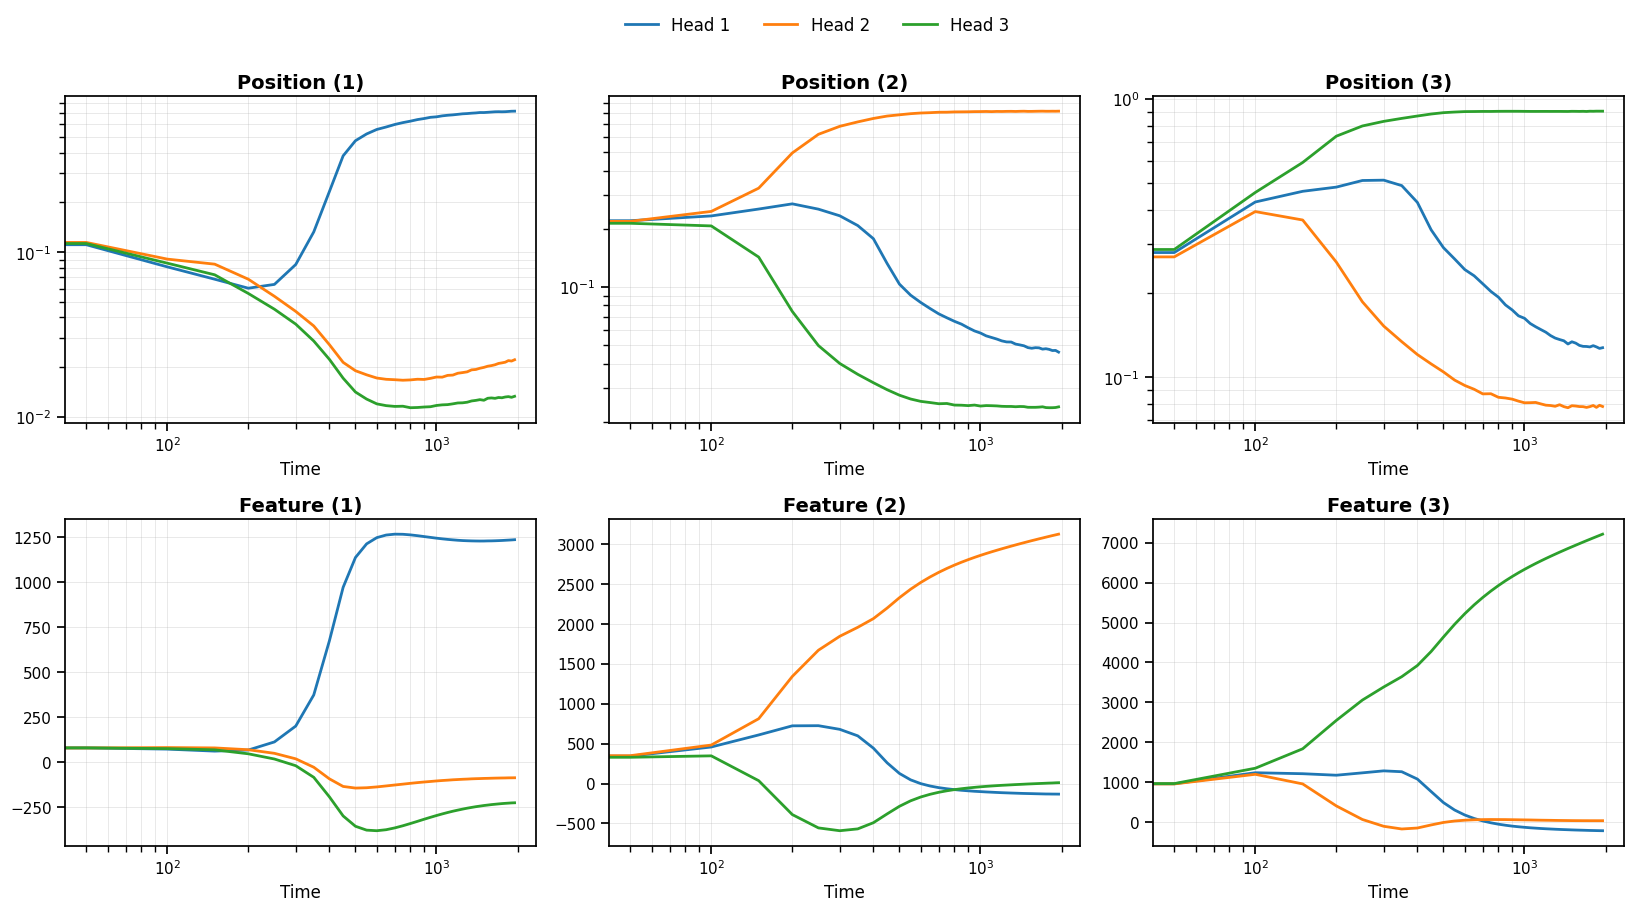

In [4]:
plot_head_dynamics(tag="ICML-minimal-model-updates")

Found 1 run(s) for tag(s) ['ICML-full-1layer']:
  distinctive-valley-1965 (am9z61y2)
Head permutation (display → original): [1, 0, 2]


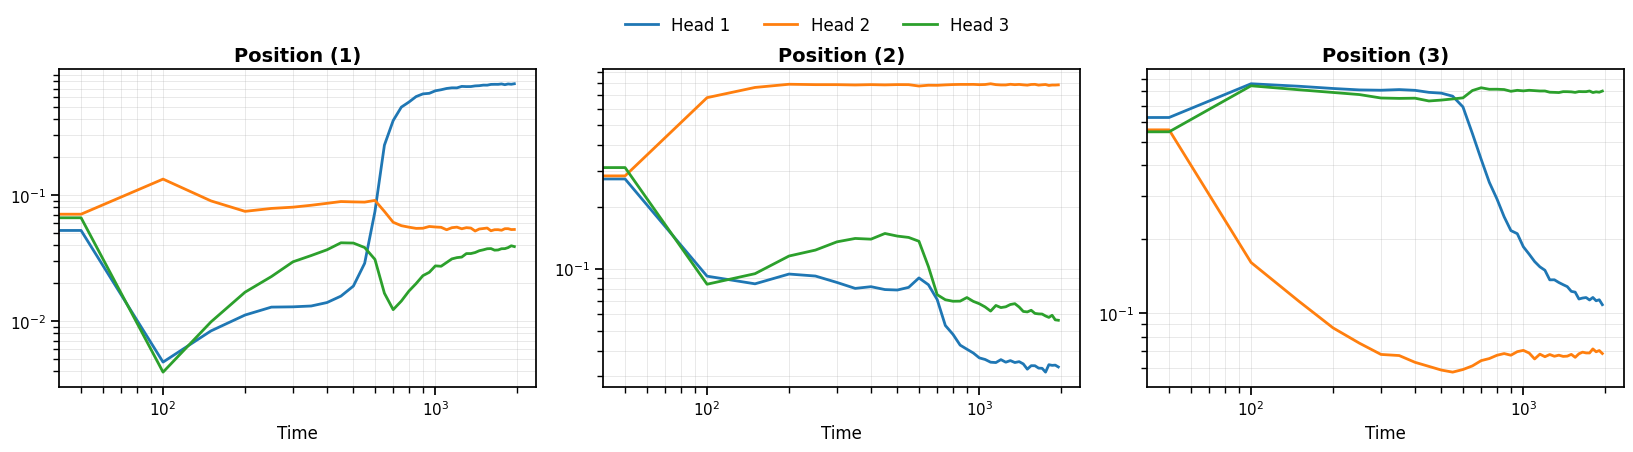

In [5]:
plot_head_dynamics(tag="ICML-full-1layer")

Found 1 run(s) for tag(s) ['ICML-minimal-small-init']:
  playful-field-1966 (3cmn17ll)
Head permutation (display → original): [2, 0, 1]
Saved to analysis/results/ICML-minimal-transformer-small-init.pdf


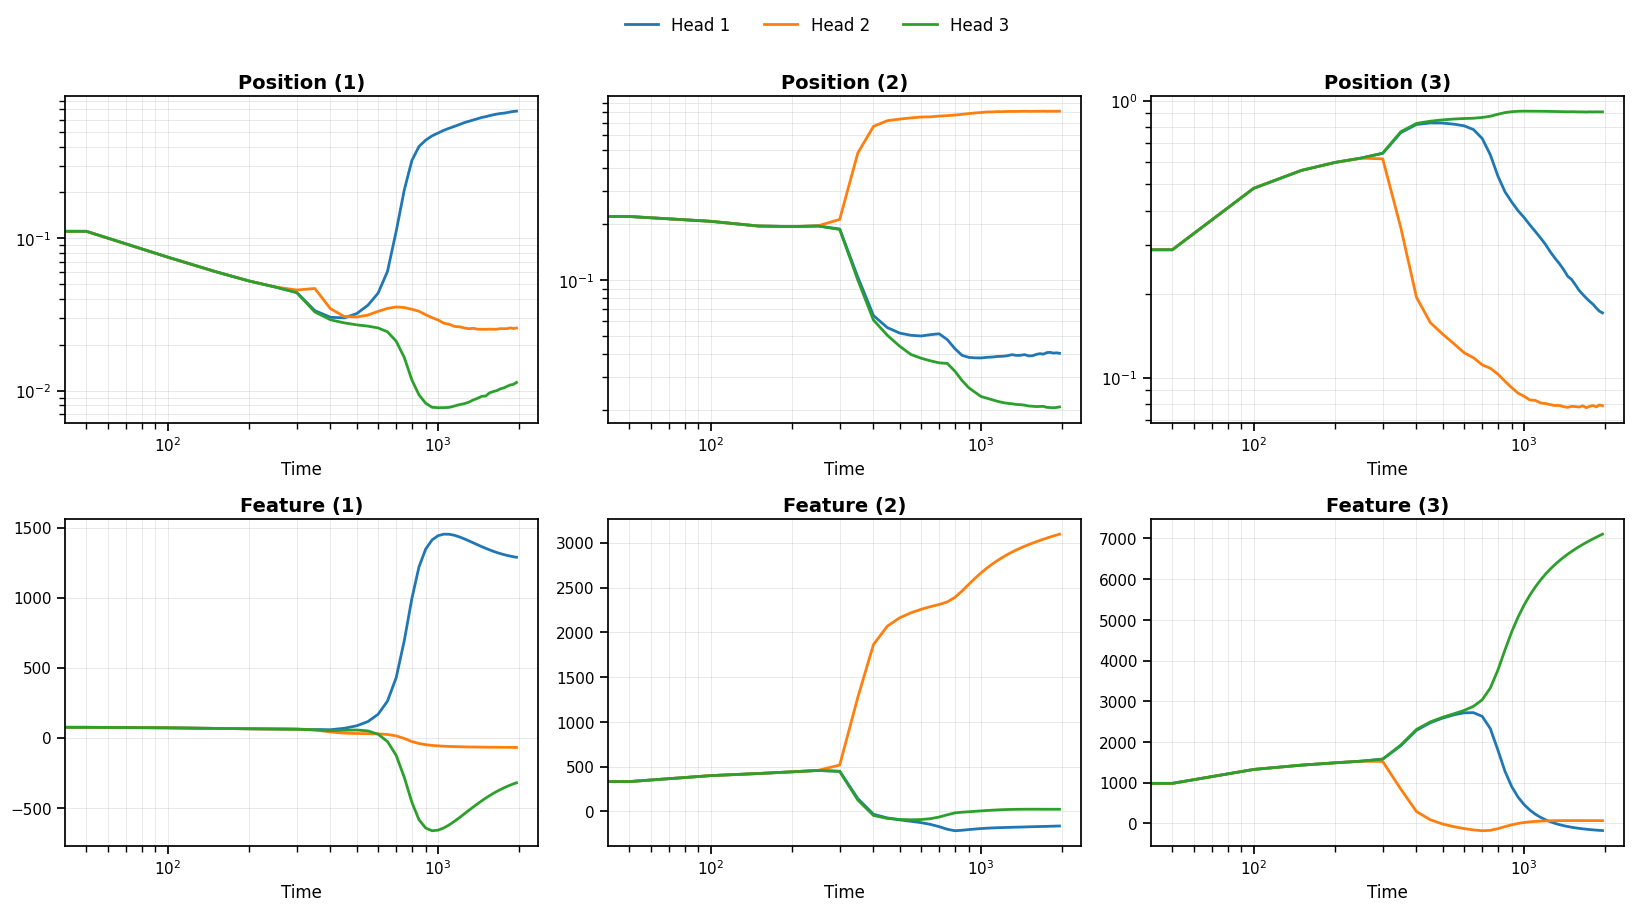

In [7]:
plot_head_dynamics(tag="ICML-minimal-small-init", save_name="ICML-minimal-transformer-small-init")